# Configure neutral sampling parameters

This notebook helps you configure unbiased ensemble generation parameters.

- No partisan metrics are computed.
- You can export a YAML config to run the full ensemble via `04_run_ensemble.py --config <yaml>`.


In [5]:
# Environment setup
import os
from pathlib import Path

# Ensure results/configurations exists
Path("results/configurations").mkdir(parents=True, exist_ok=True)

In [6]:
# User-defined tag for this configuration
config_tag = ""  # <-- Change this to something descriptive if desired

# Configure parameters (edit these values)
# Keys can be omitted - functions will use defaults for missing keys

# Constraints configuration
constraints_params = {
    "use_cut_edges": True,
    "max_muni_splits": 3,
    "max_county_splits": 3,
}

# Proposal configuration (regional surcharges)
proposal_params = {
    "muni_surcharge": 3,
    "county_surcharge": 2,
    "highered_surcharge": 1,
    "metro_surcharge": 1,
    "schdist_surcharge": 0.1,
    "water_surcharge": 0.1,
    "basin_surcharge": 0.1,
}

# Preconditioning configuration
preconditioning_params = {
    "enable": True,
    "steps": 20,
    "muni_surcharge": 3,
    "county_surcharge": 2,
    "split_munis_tolerance": 3,
    "split_counties_tolerance": 3,
}

# Ensemble configuration
ensemble_params = {
    "num_steps": 51,
    "visualize_every": 1,
    "tilted_run": 0.5,
}

# Optional fields supported by CLI; not used for neutral sampling inside this notebook
election_params = {
    "vote_share_agg": "median",
    "years": "2016,2020,2024",
    "offices": "PRE,GOV,ATG,AUD,TRE",
}

# Combined config for backward compatibility and YAML export
config = {
    "constraints": constraints_params,
    "proposal": proposal_params,
    "preconditioning": preconditioning_params,
    "ensemble": ensemble_params,
    "election": election_params,
}

In [7]:
from datetime import datetime

if config_tag:
    now_str = datetime.now().strftime("%Y%m%d%H%M%S")
    config_dir = os.path.join("results", "configurations", f"{now_str}_{config_tag}")
else:
    config_dir = os.path.join("results", "configurations", datetime.now().strftime("%Y%m%d%H%M%S"))
Path(config_dir).mkdir(parents=True, exist_ok=True)

In [8]:
# Load data and build initial partition (no elections)
from utgc.data_io import load_data, load_county_boundaries, load_municipality_boundaries
from utgc.build import create_graph, create_updaters, create_initial_partition, create_constraints, create_proposal

precincts, initial_plan = load_data()
counties = load_county_boundaries(precincts)
municipalities = load_municipality_boundaries(precincts)

graph = create_graph(precincts)
# No elections for neutral sampling
updaters = create_updaters(elections=[], election_columns={})
initial_partition = create_initial_partition(graph, precincts, updaters)

ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)
print(f"Ideal population per district: {ideal_population:,.0f}")

Loading data...
Loaded 2981 precincts
Loaded initial plan with 4 districts
Loading county boundaries from data/cois/UtahCountyBoundaries/ut_cnty_2020_bound.shp...
Loaded 29 counties
Loading municipality boundaries from data/cois/UtahMunicipalBoundaries/Municipalities.shp...
Loaded 259 municipalities
Creating graph...
Graph created with 2981 nodes and 8394 edges
Creating updaters...
Creating initial partition...
Initial partition created with 4 districts
Ideal population per district: 817,904


In [9]:
# Create constraints using the constraints parameters
constraints = create_constraints(initial_partition, **constraints_params)

# Create proposal using the proposal parameters
proposal = create_proposal(ideal_population, precincts, **proposal_params)

print("Configured parameters:")
print("Constraints params:", constraints_params)
print("Proposal params:", proposal_params)
print("Preconditioning params:", preconditioning_params)
print("Ensemble params:", ensemble_params)
print("Election params:", election_params)

Creating constraints...
Creating ReCom proposal...
Region surcharges: {'MUNIID': 3, 'COUNTYID': 2, 'HIGHERED_ID': 1, 'METRO_ID': 1, 'SCHDIST_ID': 0.1, 'BASIN_ID': 0.1, 'WATER_ID': 0.1}
Configured parameters:
Constraints params: {'use_cut_edges': True, 'max_muni_splits': 3, 'max_county_splits': 3}
Proposal params: {'muni_surcharge': 3, 'county_surcharge': 2, 'highered_surcharge': 1, 'metro_surcharge': 1, 'schdist_surcharge': 0.1, 'water_surcharge': 0.1, 'basin_surcharge': 0.1}
Preconditioning params: {'enable': True, 'steps': 20, 'muni_surcharge': 3, 'county_surcharge': 2, 'split_munis_tolerance': 3, 'split_counties_tolerance': 3}
Ensemble params: {'num_steps': 51, 'visualize_every': 1, 'tilted_run': 0.5}
Election params: {'vote_share_agg': 'median', 'years': '2016,2020,2024', 'offices': 'PRE,GOV,ATG,AUD,TRE'}


In [10]:
# Optional preconditioning step
from utgc.preconditioning import run_preconditioning

# Choose a starting partition based on whether preconditioning is enabled and constraints are satisfied
start_partition = initial_partition
if preconditioning_params.get("enable", False):
    print("Running preconditioning...")
    # Combine preconditioning params with constraints params for preconditioning
    precond_params = {**preconditioning_params, **constraints_params}
    optimized_partition = run_preconditioning(
        initial_partition,
        proposal,
        **{k: v for k, v in precond_params.items() if k in ['muni_surcharge', 'county_surcharge', 'steps', 'split_munis_tolerance', 'split_counties_tolerance']}
    )
    
    def _satisfies_all(partition, constraints_list):
        for c in constraints_list:
            try:
                if not c(partition):
                    return False
            except Exception:
                return False
        return True

    if _satisfies_all(optimized_partition, constraints):
        print("Using optimized partition as starting point.")
        start_partition = optimized_partition
    elif _satisfies_all(initial_partition, constraints):
        print("Optimized partition failed constraints; using initial partition.")
        start_partition = initial_partition
    else:
        print("Neither optimized nor initial partition meets all constraints; proceeding with initial partition and filtered constraints.")



Running preconditioning...
Running preconditioning for 20 steps...
Tolerance thresholds: pop_dev=0.0010, muni_splits=3, county_splits=3
Starting preconditioning...


100%|██████████| 20/20 [00:53<00:00,  2.65s/it]


Preconditioned score: 3.802050118351298
✗ Attempt 1 failed tolerance tests, retrying...
Retrying preconditioning (attempt 2/5)...


100%|██████████| 20/20 [00:36<00:00,  1.82s/it]


Preconditioned score: 2.8113845471677195
✗ Attempt 2 failed tolerance tests, retrying...
Retrying preconditioning (attempt 3/5)...


...

Preconditioned score: 2.7160188318759495
✗ Attempt 3 failed tolerance tests, retrying...
Retrying preconditioning (attempt 4/5)...


100%|██████████| 20/20 [00:10<00:00,  1.94it/s]


Preconditioned score: 2.7160188318759495
✗ Attempt 4 failed tolerance tests, retrying...
Retrying preconditioning (attempt 5/5)...


100%|██████████| 20/20 [00:18<00:00,  1.09it/s]

Preconditioned score: 2.446262642070463
✓ Preconditioning successful on attempt 5! All tolerances met.
Final population deviation: 0.000446
Final municipality splits: 3
Final county splits: 3
Using optimized partition as starting point.


In [11]:
# Run ensemble sample and visualize into the tag directory
from utgc.ensemble import run_ensemble, run_ensemble_tilted
from utgc.reporting import save_visualization

# Wrap visualization to write into the tag-specific directory
def _viz(partition, step, res, counties, municipalities):
    save_visualization(partition, step, res, counties, municipalities, base_dir=str(config_dir))

# Choose sampler based on tilted-run intensity (same logic as ensemble script)
tilt_intensity = max(0.0, min(1.0, float(ensemble_params["tilted_run"])))
if tilt_intensity <= 0.0:
    print("Using neutral sampler (tilted-run=0.0)")
    results = run_ensemble(
        start_partition,
        proposal,
        constraints,
        available_elections=[],
        counties=counties,
        municipalities=municipalities,
        **{k: v for k, v in ensemble_params.items() if k in ['num_steps', 'visualize_every']},
        vote_share_agg=election_params["vote_share_agg"],
        save_visualization_fn=_viz,
    )
else:
    p = 1.0 - tilt_intensity
    print(f"Using tilted-run sampler with intensity={tilt_intensity} (optimizer p={p})")
    results = run_ensemble_tilted(
        start_partition,
        proposal,
        constraints,
        available_elections=[],
        counties=counties,
        municipalities=municipalities,
        **{k: v for k, v in ensemble_params.items() if k in ['num_steps', 'visualize_every']},
        vote_share_agg=election_params["vote_share_agg"],
        save_visualization_fn=_viz,
        p=p,
    )


Using tilted-run sampler with intensity=0.5 (optimizer p=0.5)
Running tilted-run ensemble (minimize cut edges) with 51 steps and p=0.5...


100%|██████████| 51/51 [02:43<00:00,  3.21s/it]


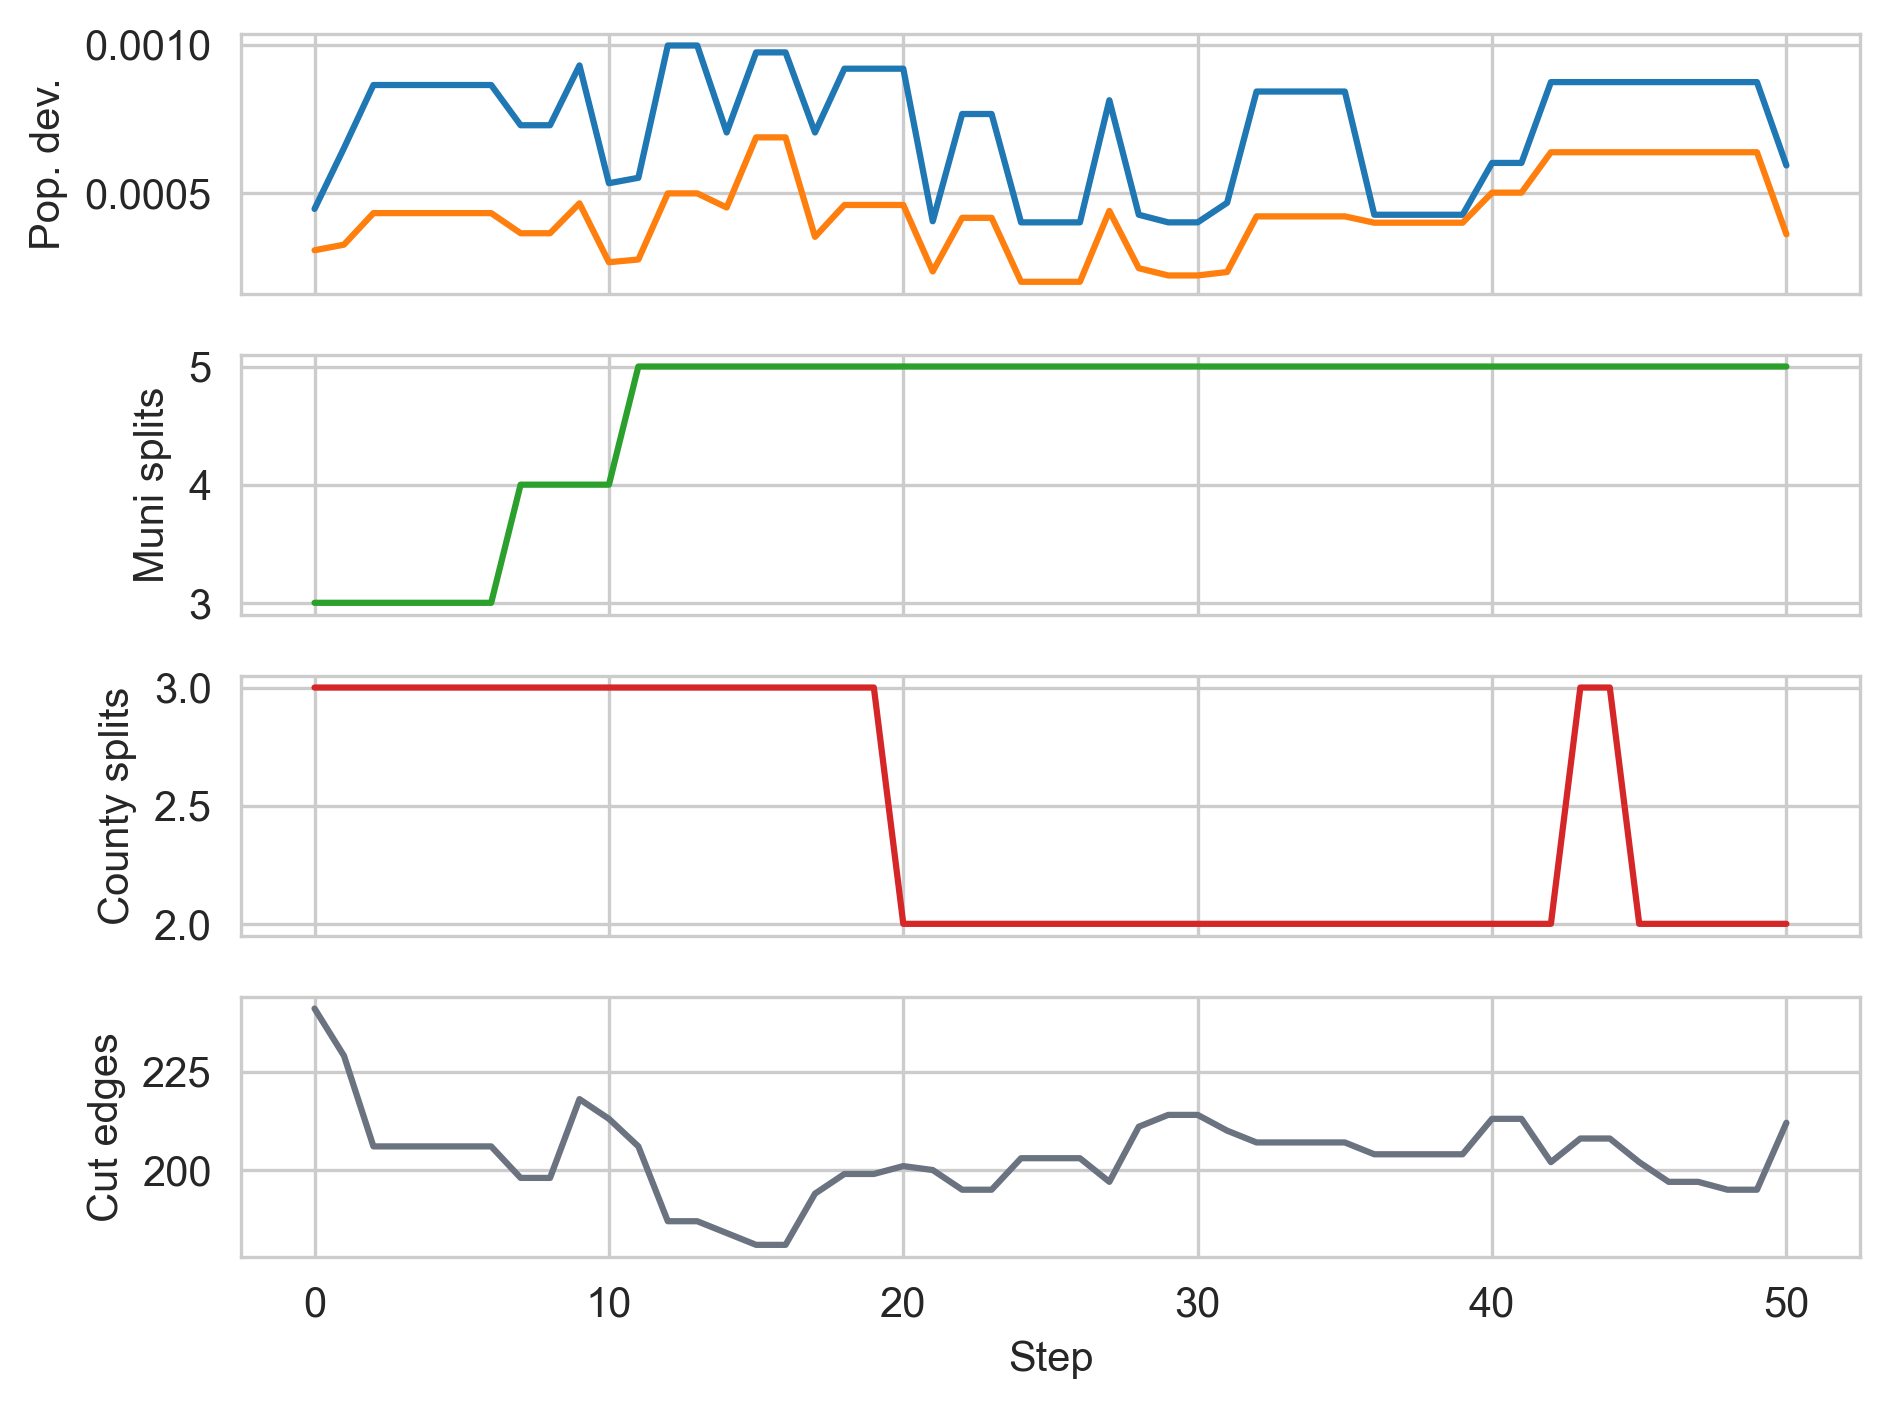

In [12]:
# Inline plots of partition-wide metrics over iterations (with cut edges)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rows = []
for r in results:
    step = r.get("step")
    split_m = r.get("split_munis_count")
    split_c = r.get("split_counties_count")
    cut_e = r.get("num_cut_edges")
    pop_dev = r.get("population_deviation", {})
    try:
        dev_vals = [v for v in pop_dev.values() if v is not None]
        max_dev = max(dev_vals) if dev_vals else None
        mean_dev = sum(dev_vals) / len(dev_vals) if dev_vals else None
    except Exception:
        max_dev = None
        mean_dev = None
    rows.append({
        "step": step,
        "split_munis_count": split_m,
        "split_counties_count": split_c,
        "population_max_dev": max_dev,
        "population_mean_dev": mean_dev,
        "num_cut_edges": cut_e,
    })

metrics_df = pd.DataFrame(rows).sort_values("step")
sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 1, sharex=True)

axes[0].plot(metrics_df["step"], metrics_df["population_max_dev"], label="Max pop dev", color="#1f77b4")
axes[0].plot(metrics_df["step"], metrics_df["population_mean_dev"], label="Mean pop dev", color="#ff7f0e")
axes[0].set_ylabel("Pop. dev.")

axes[1].plot(metrics_df["step"], metrics_df["split_munis_count"], label="Muni splits", color="#2ca02c")
axes[1].set_ylabel("Muni splits")

axes[2].plot(metrics_df["step"], metrics_df["split_counties_count"], label="County splits", color="#d62728")
axes[2].set_ylabel("County splits")

axes[3].plot(metrics_df["step"], metrics_df["num_cut_edges"], label="Cut edges", color="#6b7280")
axes[3].set_ylabel("Cut edges")
axes[3].set_xlabel("Step")

fig.set_dpi(300)
plt.tight_layout()
plt.show()

In [13]:
import os
from IPython.display import display
import ipywidgets as widgets
from PIL import Image

# Load all images saved in the config_dir directory (assumed to be PNGs)
image_dir = str(config_dir)
image_files = sorted(
    [f for f in os.listdir(image_dir) if f.lower().endswith(".png")]
)

img = widgets.Image(format='png')

steps = list(range(0, ensemble_params["num_steps"], ensemble_params["visualize_every"]))
steps2index = {s: i for i, s in enumerate(steps)}
# Slider shows actual step numbers
stepper = widgets.BoundedIntText(value=steps[0], min=min(steps), max=max(steps), step=ensemble_params["visualize_every"], description="Step:")

frames = []
for fname in image_files:
    with open(os.path.join(image_dir, fname), "rb") as f:
        data = f.read()
    frames.append(data)

# Ensure no duplicate observers if you re-run this cell
try:
    stepper.unobserve_all()
except Exception: pass

def on_change(value):
    img.value = frames[steps2index[value]]

widgets.interactive(on_change, value=stepper)
img.value = frames[steps2index[stepper.value]]

# Create and display the widget
widget_box = widgets.VBox([stepper, img])
display(widget_box)

In [14]:
# Export YAML configuration for CLI runs inside the tag folder
import yaml

yaml_path = os.path.join(config_dir, "params.yaml")
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(config, f, sort_keys=True)

print(f"Wrote YAML: {yaml_path}")

Wrote YAML: results/configurations/20251007185545/params.yaml
